In [1]:
import os, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
CURRENT_YEAR = 2026
TARGET = "selling_price"
CAT_COLS = ["brand", "fuel", "seller_type", "transmission", "owner"]
NUM_COLS = ["km_driven", "mileage", "engine", "max_power", "seats",
            "car_age", "km_per_year", "power_per_cc", "is_first_owner"]
FEATURES = CAT_COLS + NUM_COLS


def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Part 1: fix the messy raw data (units, duplicates, impossible values)."""
    df = df.drop_duplicates().copy()
    for c in ["mileage", "engine", "max_power"]:          # "23.4 kmpl" -> 23.4
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.extract(r"([\d.]+)")[0], errors="coerce")
    for c in [TARGET, "year", "km_driven"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=[TARGET, "year"])               # no label = unusable row
    df = df[(df["year"].between(1990, CURRENT_YEAR)) & (df[TARGET] > 0)]
    df.loc[(df["km_driven"] < 0) | (df["km_driven"] > 500_000), "km_driven"] = np.nan
    lo, hi = df[TARGET].quantile([0.005, 0.995])
    df = df[df[TARGET].between(lo, hi)]                   # trim crazy prices
    for c in ["fuel", "seller_type", "transmission", "owner"]:
        df[c] = df[c].astype(str).str.strip().str.title().replace("Nan", np.nan)
    return df.reset_index(drop=True)


def extract_brand(df: pd.DataFrame, min_count: int = 20) -> pd.DataFrame:
    """'Maruti Swift VDI' -> 'Maruti'. Rare brands become 'Other'."""
    df = df.copy()
    df["brand"] = df["name"].astype(str).str.split().str[0].str.title()
    counts = df["brand"].value_counts()
    df["brand"] = df["brand"].where(df["brand"].map(counts) >= min_count, "Other")
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Part 1: feature engineering."""
    df = df.copy()
    df["car_age"] = CURRENT_YEAR - df["year"]
    df["km_per_year"] = df["km_driven"] / df["car_age"].clip(lower=1)
    df["power_per_cc"] = df["max_power"] / df["engine"]
    df["is_first_owner"] = (df["owner"] == "First Owner").astype(int)
    return df

In [3]:
def make_sample_data(n=6000, seed=7):
    r = np.random.default_rng(seed)
    brands = {"Maruti": .8, "Hyundai": .95, "Honda": 1.1, "Toyota": 1.4, "Tata": .85,
              "Mahindra": 1.1, "Ford": .9, "Volkswagen": 1.0, "Skoda": 1.15, "BMW": 3.2, "Audi": 3.0}
    models = ["Swift", "i20", "City", "Innova", "Nexon", "XUV", "Figo", "Polo", "Rapid", "320d", "A4"]
    b = r.choice(list(brands), n, p=np.array([14, 13, 9, 8, 9, 8, 6, 6, 5, 3, 2]) / 83)
    year = r.integers(2004, 2026, n); age = 2026 - year
    engine = r.choice([796, 998, 1197, 1248, 1498, 1582, 1968, 2179], n)
    power = engine * r.uniform(.055, .09, n)
    fuel = r.choice(["Petrol", "Diesel", "CNG", "LPG"], n, p=[.5, .45, .04, .01])
    km = (age + r.uniform(.3, 1.5, n)) * r.uniform(5000, 15000, n)
    owner = r.choice(["First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"], n, p=[.65, .25, .08, .02])
    trans = r.choice(["Manual", "Automatic"], n, p=[.8, .2])
    base = 450000 * np.array([brands[x] for x in b]) * (engine / 1200) ** .7
    price = (base * np.exp(-.11 * age) * np.exp(-km / 400000)
             * np.where(fuel == "Diesel", 1.15, 1) * np.where(trans == "Automatic", 1.2, 1)
             * np.where(owner == "First Owner", 1.08, .9) * r.lognormal(0, .12, n))
    df = pd.DataFrame({
        "name": [f"{x} {r.choice(models)}" for x in b], "year": year, "selling_price": price.round(-3),
        "km_driven": km.round(), "fuel": fuel, "seller_type": r.choice(["Individual", "Dealer", "Trustmark Dealer"], n, p=[.8, .17, .03]),
        "transmission": trans, "owner": owner,
        "mileage": [f"{x:.1f} kmpl" for x in r.uniform(10, 26, n)],
        "engine": [f"{x} CC" for x in engine], "max_power": [f"{x:.1f} bhp" for x in power],
        "seats": r.choice([4, 5, 7], n, p=[.05, .8, .15])})
    # --- make it MESSY ---
    for c, k in [("mileage", 220), ("engine", 150), ("max_power", 150), ("seats", 150), ("km_driven", 90)]:
        df.loc[r.choice(n, k, replace=False), c] = np.nan
    df.loc[r.choice(n, 5), "km_driven"] = 9_999_999
    df.loc[r.choice(n, 4), "year"] = 2099
    df.loc[r.choice(n, 30), "fuel"] = " petrol "
    return pd.concat([df, df.sample(60, random_state=1)]).sample(frac=1, random_state=2)

In [5]:
CSV = "../datasets/cars.csv"
if not os.path.exists(CSV):
    os.makedirs("../datasets", exist_ok=True)
    make_sample_data().to_csv(CSV, index=False)
    print("sample data")
raw = pd.read_csv(CSV)
print(raw.shape); raw.head()

(6060, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Mahindra 320d,2016,255000.0,151301.0,Diesel,Individual,Manual,First Owner,12.1 kmpl,2179 CC,170.9 bhp,5.0
1,Hyundai Swift,2015,120000.0,65445.0,Petrol,Individual,Manual,First Owner,19.8 kmpl,1197 CC,78.8 bhp,5.0
2,Ford Rapid,2022,331000.0,29107.0,Diesel,Individual,Manual,First Owner,24.5 kmpl,1197 CC,73.3 bhp,5.0
3,Honda Swift,2005,26000.0,305032.0,Petrol,Individual,Manual,First Owner,19.5 kmpl,1248 CC,82.7 bhp,5.0
4,Maruti A4,2004,31000.0,133124.0,Diesel,Individual,Manual,Second Owner,18.5 kmpl,1968 CC,174.2 bhp,5.0


In [6]:
print(raw.dtypes, "\n")
print("Missing values:\n", raw.isna().sum()[raw.isna().sum() > 0])
print("\nDuplicates:", raw.duplicated().sum())
raw.describe().T

name              object
year               int64
selling_price    float64
km_driven        float64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
seats            float64
dtype: object 

Missing values:
 km_driven     91
mileage      221
engine       153
max_power    151
seats        151
dtype: int64

Duplicates: 60


,count,mean,std,min,25%,50%,75%,max
year,6060.0,2014.556436,6.759682,2004.0,2009.0,2015.0,2020.0,2099.0
selling_price,6060.0,189685.313531,199527.081112,8000.0,56000.0,123000.0,259000.0,2173000.0
km_driven,5969.0,133405.749707,295754.618445,7054.0,62495.0,114144.0,177527.0,9999999.0
seats,5909.0,5.251142,0.759203,4.0,5.0,5.0,5.0,7.0


In [7]:
df = clean(raw)
df = extract_brand(df)      # feature 1: brand from name
df = add_features(df)       # features 2-5: car_age, km_per_year, power_per_cc, is_first_owner
print(f"Rows: {len(raw)} -> {len(df)}")
df[["name","brand","year","car_age","km_driven","km_per_year","power_per_cc","is_first_owner",TARGET]].head()

Rows: 6060 -> 5945


,name,brand,year,car_age,km_driven,km_per_year,power_per_cc,is_first_owner,selling_price
0,Mahindra 320d,Mahindra,2016,10,151301.0,15130.100000,0.078430,1,255000.0
1,Hyundai Swift,Hyundai,2015,11,65445.0,5949.545455,0.065831,1,120000.0
2,Ford Rapid,Ford,2022,4,29107.0,7276.750000,0.061236,1,331000.0
3,Honda Swift,Honda,2005,21,305032.0,14525.333333,0.066266,1,26000.0
4,Maruti A4,Maruti,2004,22,133124.0,6051.090909,0.088516,0,31000.0


In [8]:
LEAKY = ["name", "year", TARGET]
X = df[FEATURES]; y = df[TARGET]
assert not set(LEAKY) & set(X.columns)
corr = X.select_dtypes("number").corrwith(y).abs().sort_values(ascending=False)
print(corr.round(3).to_string())
print("\nSuspicious (>0.95):", corr[corr > 0.95].index.tolist())

car_age           0.761
km_driven         0.672
km_per_year       0.256
engine            0.198
max_power         0.180
is_first_owner    0.072
power_per_cc      0.017
seats             0.016
mileage           0.002

Suspicious (>0.95): []


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(4756, 14) (1189, 14)


In [10]:
prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUM_COLS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT_COLS),
])
rf = Pipeline([("prep", prep),
               ("rf", RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42))])
# prices are right-skewed -> learn on log(price), predictions come back in rupees
model = TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1)
model.fit(X_train, y_train)

,regressor,Pipeline(step...m_state=42))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [11]:
pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)
print(f"MAE  : Rs {mae:,.0f}   (average miss)")
print(f"RMSE : Rs {rmse:,.0f}  (big misses punished more)")
print(f"R2   : {r2:.3f}")
print(f"Median price: Rs {y_test.median():,.0f} -> MAE is {mae / y_test.median():.0%} of a typical car")

MAE  : Rs 25,263   (average miss)
RMSE : Rs 44,632  (big misses punished more)
R2   : 0.925
Median price: Rs 117,000 -> MAE is 22% of a typical car


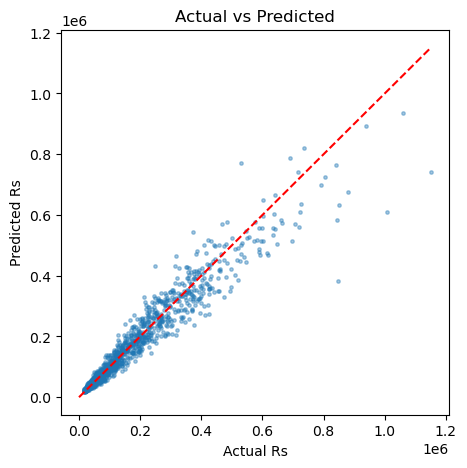

In [12]:
plt.figure(figsize=(5,5)); plt.scatter(y_test, pred, s=6, alpha=.4)
m = max(y_test.max(), pred.max()); plt.plot([0,m],[0,m],"r--")
plt.xlabel("Actual Rs"); plt.ylabel("Predicted Rs"); plt.title("Actual vs Predicted"); plt.show()

Top 5 features:
  car_age          80.2%
  brand             8.6%
  engine            3.7%
  max_power         2.2%
  km_driven         2.0%


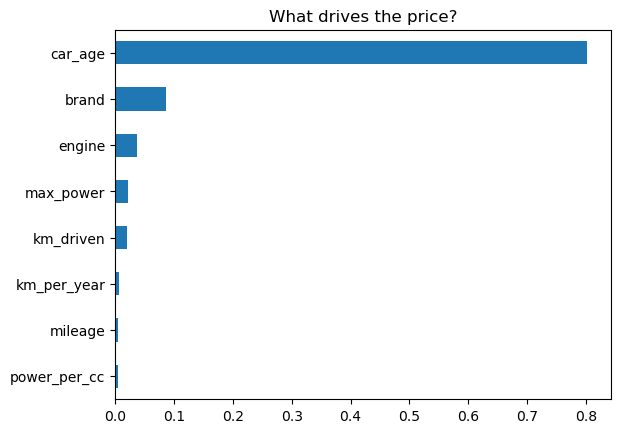

In [13]:
fitted = model.regressor_
names = fitted.named_steps["prep"].get_feature_names_out()
imp = fitted.named_steps["rf"].feature_importances_
grouped = {}
for n, v in zip(names, imp):
    n = n.split("__", 1)[1]
    key = next((c for c in CAT_COLS if n.startswith(c + "_")), n)
    grouped[key] = grouped.get(key, 0) + v
importance = dict(sorted(grouped.items(), key=lambda kv: -kv[1]))
print("Top 5 features:")
for k, v in list(importance.items())[:5]: print(f"  {k:<16}{v:6.1%}")
pd.Series(importance).head(8)[::-1].plot.barh(title="What drives the price?"); plt.show()

In [14]:
new_car = pd.DataFrame([{"brand":"Hyundai","fuel":"Petrol","seller_type":"Individual","transmission":"Manual",
    "owner":"First Owner","year":2019,"km_driven":45000,"mileage":19.0,"engine":1197,"max_power":82,"seats":5}])
new_car = add_features(new_car)[FEATURES]
print(f"Predicted price: Rs {model.predict(new_car)[0]:,.0f}")

Predicted price: Rs 208,892


In [16]:
bundle = {
    "model": model, "importance": importance,
    "metrics": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "brands": sorted(X["brand"].unique()),
    "options": {c: sorted(X[c].dropna().unique()) for c in ["fuel","seller_type","transmission","owner"]},
    "defaults": X_train[["mileage","engine","max_power","seats"]].median().to_dict(),
}
joblib.dump(bundle, "../backend/price_model.joblib")
print("Saved backend/price_model.joblib ")

Saved backend/price_model.joblib 


In [17]:
import sklearn, sys
print(sklearn.__version__, sys.executable)

1.7.2 C:\Users\Hp\anaconda3\python.exe


In [18]:
import sklearn
bundle = {
    "sklearn_version": sklearn.__version__,
    "model": model, "importance": importance,
    "metrics": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "brands": sorted(X["brand"].unique()),
    "options": {c: sorted(X[c].dropna().unique()) for c in ["fuel","seller_type","transmission","owner"]},
    "defaults": X_train[["mileage","engine","max_power","seats"]].median().to_dict(),
}
joblib.dump(bundle, "../backend/price_model.joblib")
print("Saved backend/price_model.joblib")

Saved backend/price_model.joblib
